setting up environment with old tokenizer for hyper parameter tuning

In [1]:
# --- 1. SETUP ENVIRONMENT ---
!pip install datasets
import numpy as np
import pandas as pd
import re
import os
import pickle
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("⚙️ INITIALIZING TUNING LAB...")

# --- 2. LOAD TOKENIZER ---
tokenizer_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('tokenizer.pkl'):
            tokenizer_path = os.path.join(root, file)
            break

if tokenizer_path:
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)
    VOCAB_SIZE = len(tokenizer.word_index) + 1
    print(f"✅ Tokenizer Loaded (Vocab: {VOCAB_SIZE})")
else:
    raise FileNotFoundError("❌ tokenizer.pkl not found! Upload it to Input.")

# --- 3. LOAD & CLEAN DATA ---
print("📥 Loading Dataset...")
dataset = load_dataset("ReySajju742/Urdu-Poetry-Dataset")
df = dataset['train'].to_pandas()

all_verses = []
for poem in df['content']:
    if poem:
        lines = poem.split('\n')
        for line in lines:
            text = re.sub(r'[a-zA-Z0-9]', '', line)
            text = re.sub(r'[()\[\]{}|\\/<>@#$%^&*_+=]', '', text)
            text = re.sub(r'\s+', ' ', text).strip()
            if len(text) > 5:
                all_verses.append(text)

# --- 4. PREPARE SEQUENCES ---
print("🔄 Processing Sequences...")
input_sequences = []
for line in all_verses:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

MAX_SEQ_LEN = 20 # Baseline Requirement
input_sequences = np.array(pad_sequences(input_sequences, maxlen=MAX_SEQ_LEN, padding='pre'))
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"✅ DATA READY. Train: {len(X_train)} | Val: {len(X_val)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 43.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pylibcudf-cu12==25.6.*, but you have pylibcudf-cu12 25.2.2 which is incompatible.


2025-11-29 12:23:51.814636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764419032.012833      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764419032.074534      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

⚙️ INITIALIZING TUNING LAB...
✅ Tokenizer Loaded (Vocab: 10508)
📥 Loading Dataset...


README.md: 0.00B [00:00, ?B/s]

output_ur.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1323 [00:00<?, ? examples/s]

🔄 Processing Sequences...
✅ DATA READY. Train: 121716 | Val: 15215


**Training hyper paramater tuned models**

In [ ]:
import math
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping

# --- CONFIGURATION ---
EMBEDDING_DIM = 100 
RNN_UNITS = 150
#  VOCAB_SIZE and MAX_SEQ_LEN come from Step 2

# --- 1. Baseline for each architecture ---
winners = [
    {"type": "RNN",         "opt": "Adam",    "base_lr": 0.001},
    {"type": "LSTM",        "opt": "RMSprop", "base_lr": 0.001},
    {"type": "Transformer", "opt": "SGD",     "base_lr": 0.01}
]

# --- 2.  EXPERIMENTS ---
# Standard changes apply to all model types
standard_changes = [
    {"tag": "Layers_3",    "param": "layers", "value": 3},
    {"tag": "Drop_0.5",    "param": "drop",   "value": 0.5},
    {"tag": "LR_0.0001",   "param": "lr",     "value": 0.0001},
    {"tag": "Batch_256",   "param": "batch",  "value": 256},
    {"tag": "Epoch_50",    "param": "epoch",  "value": 50}
]

# Special changes apply ONLY to Transformer
transformer_specials = [
    {"tag": "Heads_8",     "param": "heads",  "value": 8},
    {"tag": "Dim_1024",    "param": "ff_dim", "value": 1024},
    {"tag": "Blocks_4",    "param": "blocks", "value": 4}
]

# --- 3. TRANSFORMER CLASSES ---
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer(cfg):
    inputs = layers.Input(shape=(MAX_SEQ_LEN-1,))
    x = TokenAndPositionEmbedding(MAX_SEQ_LEN-1, VOCAB_SIZE, EMBEDDING_DIM)(inputs)
    
    # Use 'blocks' if specified (special), otherwise use 'layers' (standard)
    num_blocks = cfg.get('blocks', cfg['layers']) 
    
    for _ in range(num_blocks):
        x = TransformerBlock(EMBEDDING_DIM, cfg['heads'], cfg['ff_dim'], rate=cfg['drop'])(x)
        
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)
    return models.Model(inputs=inputs, outputs=outputs)

# --- 4. THE GRAND LOOP ---
results = []
print("🚀 STARTING 18-MODEL HYPERPARAMETER TUNING...")

for winner in winners:
    m_type = winner['type']
    
    # Determine which experiments to run for this model
    current_experiments = standard_changes.copy()
    if m_type == "Transformer":
        current_experiments += transformer_specials
        
    print(f"\n[{m_type}] Running {len(current_experiments)} experiments...")
    
    for exp in current_experiments:
        # A. SET BASELINE DEFAULTS
        cfg = {
            "layers": 2, "drop": 0.2, "lr": winner['base_lr'], 
            "batch": 128, "epoch": 20,
            # Transformer defaults
            "heads": 4, "ff_dim": 512, "blocks": 2 
        }
        
        # B. APPLY CHANGE
        cfg[exp['param']] = exp['value']
        
        # Generate clean name
        model_name = f"Tuning_{m_type}_{winner['opt']}_{exp['tag']}"
        print(f"  -> Training {model_name}...")
        
        # C. BUILD MODEL
        model = None
        if m_type == "RNN":
            model = Sequential()
            model.add(Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQ_LEN-1))
            for i in range(cfg['layers'] - 1):
                model.add(SimpleRNN(RNN_UNITS, return_sequences=True))
                model.add(Dropout(cfg['drop']))
            model.add(SimpleRNN(RNN_UNITS, return_sequences=False))
            model.add(Dropout(cfg['drop']))
            model.add(Dense(VOCAB_SIZE, activation='softmax'))
            
        elif m_type == "LSTM":
            model = Sequential()
            model.add(Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQ_LEN-1))
            for i in range(cfg['layers'] - 1):
                model.add(LSTM(RNN_UNITS, return_sequences=True))
                model.add(Dropout(cfg['drop']))
            model.add(LSTM(RNN_UNITS, return_sequences=False))
            model.add(Dropout(cfg['drop']))
            model.add(Dense(VOCAB_SIZE, activation='softmax'))
            
        elif m_type == "Transformer":
            model = build_transformer(cfg)

        # D. COMPILE
        opt = None
        if winner['opt'] == "Adam": opt = Adam(learning_rate=cfg['lr'])
        elif winner['opt'] == "RMSprop": opt = RMSprop(learning_rate=cfg['lr'])
        elif winner['opt'] == "SGD": opt = SGD(learning_rate=cfg['lr'], momentum=0.9)
        
        model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
        
        # E. TRAIN
        # Patience increased to 5 for tuning to let models converge
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        
        history = model.fit(
            X_train, y_train,
            epochs=cfg['epoch'],
            batch_size=cfg['batch'],
            validation_data=(X_val, y_val),
            callbacks=[early_stop],
            verbose=0 # Quiet mode
        )
        
        # F. SAVE & LOG
        # Save model file
        model.save(f"{model_name}.keras")
        
        # Log metrics
        best_loss = min(history.history['val_loss'])
        perplexity = math.exp(best_loss)
        print(f"     ✅ Saved. Perplexity: {perplexity:.2f}")
        
        results.append({
            "Model": m_type,
            "Optimizer": winner['opt'],
            "Experiment": exp['tag'],
            "Parameter": exp['param'],
            "Value": exp['value'],
            "Perplexity": perplexity,
            "Filename": f"{model_name}.keras"
        })

# --- 5. SAVE CSV ---
df_tuning = pd.DataFrame(results)
df_tuning.to_csv("FINAL_TUNING_RESULTS.csv", index=False)
print("\n🎉 ALL 18 EXPERIMENTS COMPLETED SUCCESSFULLY!")
display(df_tuning)

🚀 STARTING 18-MODEL HYPERPARAMETER TUNING...

[RNN] Running 5 experiments...
  -> Training Tuning_RNN_Adam_Layers_3...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1764419061.082394      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764419061.083158      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1764419064.582355     126 service.cc:148] XLA service 0x78df68003f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764419064.583019     126 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764419064.583039     126 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capabili

     ✅ Saved. Perplexity: 805.83
  -> Training Tuning_RNN_Adam_Drop_0.5...
     ✅ Saved. Perplexity: 629.05
  -> Training Tuning_RNN_Adam_LR_0.0001...
     ✅ Saved. Perplexity: 813.39
  -> Training Tuning_RNN_Adam_Batch_256...
     ✅ Saved. Perplexity: 633.61
  -> Training Tuning_RNN_Adam_Epoch_50...
     ✅ Saved. Perplexity: 616.82

[LSTM] Running 5 experiments...
  -> Training Tuning_LSTM_RMSprop_Layers_3...
     ✅ Saved. Perplexity: 620.28
  -> Training Tuning_LSTM_RMSprop_Drop_0.5...
     ✅ Saved. Perplexity: 611.31
  -> Training Tuning_LSTM_RMSprop_LR_0.0001...
     ✅ Saved. Perplexity: 949.77
  -> Training Tuning_LSTM_RMSprop_Batch_256...
     ✅ Saved. Perplexity: 590.73
  -> Training Tuning_LSTM_RMSprop_Epoch_50...
     ✅ Saved. Perplexity: 591.39

[Transformer] Running 8 experiments...
  -> Training Tuning_Transformer_SGD_Layers_3...
     ✅ Saved. Perplexity: 517.87
  -> Training Tuning_Transformer_SGD_Drop_0.5...
     ✅ Saved. Perplexity: 618.82
  -> Training Tuning_Transforme

,Model,Optimizer,Experiment,Parameter,Value,Perplexity,Filename
0,RNN,Adam,Layers_3,layers,3.0000,805.828297,Tuning_RNN_Adam_Layers_3.keras
1,RNN,Adam,Drop_0.5,drop,0.5000,629.052264,Tuning_RNN_Adam_Drop_0.5.keras
2,RNN,Adam,LR_0.0001,lr,0.0001,813.392552,Tuning_RNN_Adam_LR_0.0001.keras
3,RNN,Adam,Batch_256,batch,256.0000,633.613950,Tuning_RNN_Adam_Batch_256.keras
4,RNN,Adam,Epoch_50,epoch,50.0000,616.821758,Tuning_RNN_Adam_Epoch_50.keras
5,LSTM,RMSprop,Layers_3,layers,3.0000,620.282381,Tuning_LSTM_RMSprop_Layers_3.keras
6,LSTM,RMSprop,Drop_0.5,drop,0.5000,611.307036,Tuning_LSTM_RMSprop_Drop_0.5.keras
7,LSTM,RMSprop,LR_0.0001,lr,0.0001,949.770828,Tuning_LSTM_RMSprop_LR_0.0001.keras
8,LSTM,RMSprop,Batch_256,batch,256.0000,590.731150,Tuning_LSTM_RMSprop_Batch_256.keras
9,LSTM,RMSprop,Epoch_50,epoch,50.0000,591.391501,Tuning_LSTM_RMSprop_Epoch_50.keras


**Calculating Accuracy**

In [ ]:
import os
import math
import re
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models, optimizers

# --- 1. RE-DEFINE TRANSFORMER CLASSES & BUILDER ---
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
    def call(self, x):
        import tensorflow as tf
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Config
VOCAB_SIZE = 10508 
MAX_SEQ_LEN = 20
EMBEDDING_DIM = 100 

def build_transformer_skeleton(cfg):
    inputs = layers.Input(shape=(MAX_SEQ_LEN-1,))
    x = TokenAndPositionEmbedding(MAX_SEQ_LEN-1, VOCAB_SIZE, EMBEDDING_DIM)(inputs)
    
    # Logic to handle 'layers' vs 'blocks' naming
    count = cfg.get('blocks', cfg.get('layers', 2))
    
    for _ in range(int(count)):
        x = TransformerBlock(EMBEDDING_DIM, int(cfg['heads']), int(cfg['ff_dim']), rate=float(cfg['drop']))(x)
        
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)
    return models.Model(inputs=inputs, outputs=outputs)

# --- 2. THE RESCUE SCOREBOARD LOOP ---
print("🏆 FINAL TUNING SCOREBOARD (RESCUE MODE) 🏆\n")
print(f"{'MODEL':<15} | {'OPTIMIZER':<10} | {'EXPERIMENT':<15} | {'ACCURACY':<10} | {'PERPLEXITY'}")
print("-" * 75)

model_files = []
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.startswith('Tuning_') and file.endswith('.keras'):
            model_files.append(os.path.join(root, file))

for model_path in model_files:
    filename = os.path.basename(model_path)
    # Parse filename: Tuning_TYPE_OPT_TAG_VALUE.keras
    parts = filename.replace('.keras', '').split('_')
    m_type = parts[1]
    opt = parts[2]
    # Reconstruct the tag (e.g., Heads_8 or Layers_3)
    tag_name = parts[3]
    tag_val = parts[4]
    full_tag = f"{tag_name}_{tag_val}"

    try:
        model = None
        # A. Try Standard Load (Works for RNN/LSTM)
        try:
            model = load_model(model_path, custom_objects={
                "TokenAndPositionEmbedding": TokenAndPositionEmbedding,
                "TransformerBlock": TransformerBlock
            })
        except:
            # B. Rescue Mode (For Transformer)
            if m_type == "Transformer":
                # 1. Start with Baseline Config
                cfg = {"layers": 2, "drop": 0.2, "heads": 4, "ff_dim": 512, "blocks": 2}
                
                # 2. Update Config based on Filename Tag
                if tag_name == "Layers": cfg['layers'] = tag_val
                elif tag_name == "Blocks": cfg['blocks'] = tag_val
                elif tag_name == "Drop": cfg['drop'] = tag_val
                elif tag_name == "Heads": cfg['heads'] = tag_val
                elif tag_name == "Dim": cfg['ff_dim'] = tag_val
                # Note: LR, Batch, Epoch tags don't change architecture, so baseline config is fine
                
                # 3. Build & Load Weights
                model = build_transformer_skeleton(cfg)
                model.load_weights(model_path)
                model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        if model:
            loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
            perplexity = math.exp(loss)
            print(f"{m_type:<15} | {opt:<10} | {full_tag:<15} | {accuracy*100:.2f}%     | {perplexity:.2f}")
        else:
            print(f"❌ Could not rescue {filename}")

    except Exception as e:
        print(f"❌ Error processing {filename}: {e}")

print("-" * 75)

🏆 FINAL TUNING SCOREBOARD (RESCUE MODE) 🏆

MODEL           | OPTIMIZER  | EXPERIMENT      | ACCURACY   | PERPLEXITY
---------------------------------------------------------------------------
RNN             | Adam       | Layers_3        | 6.76%     | 805.83
Transformer     | SGD        | Heads_8         | 8.77%     | 519.65
RNN             | Adam       | LR_0.0001       | 4.61%     | 813.39
Transformer     | SGD        | Drop_0.5        | 8.74%     | 618.82
LSTM            | RMSprop    | LR_0.0001       | 4.52%     | 949.77
Transformer     | SGD        | LR_0.0001       | 4.52%     | 890.97
Transformer     | SGD        | Blocks_4        | 9.18%     | 516.29
Transformer     | SGD        | Dim_1024        | 9.06%     | 518.25
LSTM            | RMSprop    | Batch_256       | 7.92%     | 590.73
Transformer     | SGD        | Batch_256       | 8.91%     | 547.17
LSTM            | RMSprop    | Epoch_50        | 8.66%     | 591.39
RNN             | Adam       | Batch_256       | 8.54%     |

**Text generations**

In [5]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

# --- 1. CONFIGURATION ---
MAX_SEQ_LEN = 20
VOCAB_SIZE = 10508 
EMBEDDING_DIM = 100
SEED_WORD = "محبت"
TEMP = 1.0

# --- 2. DEFINE CLASSES & BUILDER (For Rescue) ---
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer_skeleton(cfg):
    inputs = layers.Input(shape=(MAX_SEQ_LEN-1,))
    x = TokenAndPositionEmbedding(MAX_SEQ_LEN-1, VOCAB_SIZE, EMBEDDING_DIM)(inputs)
    count = cfg.get('blocks', cfg.get('layers', 2))
    for _ in range(int(count)):
        x = TransformerBlock(EMBEDDING_DIM, int(cfg['heads']), int(cfg['ff_dim']), rate=float(cfg['drop']))(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)
    return models.Model(inputs=inputs, outputs=outputs)

# --- 3. GENERATOR FUNCTION ---
def generate_poetry(model, seed_text, next_words=12, temperature=1.0):
    generated_text = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated_text])[0]
        token_list = pad_sequences([token_list], maxlen=MAX_SEQ_LEN-1, padding='pre')
        predictions = model.predict(token_list, verbose=0)[0]
        predictions = np.log(predictions + 1e-7) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)
        predicted_id = np.random.choice(len(predictions), p=predictions)
        
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                output_word = word
                break
        generated_text += " " + output_word
    return generated_text

# --- 4. EXECUTE & SAVE TO CSV ---
print(f"📝 GENERATING 18 TEXTS (Seed: '{SEED_WORD}', Temp: {TEMP})\n")

results = []
model_files = []
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.startswith('Tuning_') and file.endswith('.keras'):
            model_files.append(os.path.join(root, file))

for model_path in model_files:
    filename = os.path.basename(model_path)
    
    # Parse filename for rescue info
    parts = filename.replace('.keras', '').split('_')
    m_type = parts[1]
    opt = parts[2]
    tag_name = parts[3]
    tag_val = parts[4]
    full_experiment = f"{tag_name}_{tag_val}"
    
    try:
        model = None
        # Try Standard Load
        try:
            model = load_model(model_path, custom_objects={
                "TokenAndPositionEmbedding": TokenAndPositionEmbedding,
                "TransformerBlock": TransformerBlock
            })
        except:
            # Rescue Mode for Transformers
            if m_type == "Transformer":
                cfg = {"layers": 2, "drop": 0.2, "heads": 4, "ff_dim": 512, "blocks": 2}
                if tag_name == "Layers": cfg['layers'] = tag_val
                elif tag_name == "Blocks": cfg['blocks'] = tag_val
                elif tag_name == "Drop": cfg['drop'] = tag_val
                elif tag_name == "Heads": cfg['heads'] = tag_val
                elif tag_name == "Dim": cfg['ff_dim'] = tag_val
                
                model = build_transformer_skeleton(cfg)
                model.load_weights(model_path)
        
        if model:
            text = generate_poetry(model, SEED_WORD, next_words=12, temperature=TEMP)
            print(f"🔹 {filename}")
            print(f"   📜 {text}\n")
            
            results.append({
                "Model": m_type,
                "Optimizer": opt,
                "Experiment": full_experiment,
                "Generated_Text": text,
                "Filename": filename
            })
        else:
            print(f"❌ Could not load {filename}")
            
    except Exception as e:
        print(f"❌ Error: {e}")

# --- SAVE TO CSV ---
df_results = pd.DataFrame(results)
# Sort for tidiness
df_results = df_results.sort_values(by=['Model', 'Experiment'])

# Encoding 'utf-8-sig' fixes the Urdu characters in Excel
df_results.to_csv("TUNED_MODELS_POETRY.csv", index=False, encoding='utf-8-sig')

print("\n✅ SAVED SUCCESSFULLY!")
print("Download 'TUNED_MODELS_POETRY.csv' from the Output section.")
display(df_results)

📝 GENERATING 18 TEXTS (Seed: 'محبت', Temp: 1.0)

🔹 Tuning_RNN_Adam_Layers_3.keras
   📜 محبت باقی مری قرض لب آ جاتا مجھے دیکھتے ہیں فصاد نصیب آ

🔹 Tuning_Transformer_SGD_Heads_8.keras
   📜 محبت آپ یوں کر دے گیا اس کو نہیں تھی وہ کہیں خوف

🔹 Tuning_RNN_Adam_LR_0.0001.keras
   📜 محبت میں ایسی بہ شکست عشق اکرام بھی فتح بار ہوئے نہ ہوں

🔹 Tuning_Transformer_SGD_Drop_0.5.keras
   📜 محبت ہے کہ چکیدن سی دوستی سے کہیں دل سے ہیں اور ابھی

🔹 Tuning_LSTM_RMSprop_LR_0.0001.keras
   📜 محبت پارس ذرا نہ ہو کو دل ابل را رہے آنکھ نے نے

🔹 Tuning_Transformer_SGD_LR_0.0001.keras
   📜 محبت صبح گر تعب اس زینہ ہیں بلبلہ تھا آئیں جھانکا بھاری میں

🔹 Tuning_Transformer_SGD_Blocks_4.keras
   📜 محبت و ذوق بکف جو عالم طفلاں تھا رنگ و پڑھوں کا کام

🔹 Tuning_Transformer_SGD_Dim_1024.keras
   📜 محبت وہ غبار رنگ اشک ہے کوئی بات نہیں باقی ہے میاں کی

🔹 Tuning_LSTM_RMSprop_Batch_256.keras
   📜 محبت میں بس کہنا دو فولاد نہیں ہوتا چلے ہوں میں مری کار

🔹 Tuning_Transformer_SGD_Batch_256.keras
   📜 محبت کو کاٹ کے راہنما ہ

,Model,Optimizer,Experiment,Generated_Text,Filename
8,LSTM,RMSprop,Batch_256,محبت میں بس کہنا دو فولاد نہیں ہوتا چلے ہوں می...,Tuning_LSTM_RMSprop_Batch_256.keras
17,LSTM,RMSprop,Drop_0.5,محبت اتنا کیا ہے ایک بے مشک کرتی ہے نماۓ جھگڑو...,Tuning_LSTM_RMSprop_Drop_0.5.keras
10,LSTM,RMSprop,Epoch_50,محبت تھی کس تھی ادائے و مند ہوں نہ گریہ کی لال...,Tuning_LSTM_RMSprop_Epoch_50.keras
4,LSTM,RMSprop,LR_0.0001,محبت پارس ذرا نہ ہو کو دل ابل را رہے آنکھ نے نے,Tuning_LSTM_RMSprop_LR_0.0001.keras
13,LSTM,RMSprop,Layers_3,محبت تک تو ذقن راہ تو کسے کریں گا کوئی کچھ آتا ہے,Tuning_LSTM_RMSprop_Layers_3.keras
11,RNN,Adam,Batch_256,محبت مجھے قرار اپنے آ سے کہا کیا جائیے ہے معلو...,Tuning_RNN_Adam_Batch_256.keras
16,RNN,Adam,Drop_0.5,محبت رہزن سلسلہ پھر میں نے تب کے کرامت کہنے کا...,Tuning_RNN_Adam_Drop_0.5.keras
12,RNN,Adam,Epoch_50,محبت کسی شوخ دیکھوں ہے داغ جو اندر تمنا سے تیر...,Tuning_RNN_Adam_Epoch_50.keras
2,RNN,Adam,LR_0.0001,محبت میں ایسی بہ شکست عشق اکرام بھی فتح بار ہو...,Tuning_RNN_Adam_LR_0.0001.keras
0,RNN,Adam,Layers_3,محبت باقی مری قرض لب آ جاتا مجھے دیکھتے ہیں فص...,Tuning_RNN_Adam_Layers_3.keras


**Generated text Evaluations**

In [ ]:
import pandas as pd
import numpy as np
import os

# --- CONFIGURATION ---
CSV_FILENAME = "TUNED_MODELS_POETRY.csv" 

# --- 1. DEFINE METRIC FUNCTIONS ---
def get_vocab_diversity(text):
    """Unique words / Total words"""
    words = str(text).split()
    if len(words) == 0: return 0
    unique_words = set(words)
    return len(unique_words) / len(words)

def get_avg_word_length(text):
    """Character count per word"""
    words = str(text).split()
    if len(words) == 0: return 0
    char_count = sum(len(w) for w in words)
    return char_count / len(words)

def get_repetition_rate(text):
    """Repeated phrases count (Trigrams)"""
    words = str(text).split()
    if len(words) < 3: return 0
    trigrams = [" ".join(words[i:i+3]) for i in range(len(words)-2)]
    counts = pd.Series(trigrams).value_counts()
    repeats = counts[counts > 1].sum()
    return repeats / len(trigrams)

# --- 2. LOAD AND CALCULATE ---
print("Searching for Tuned Poetry file...")
csv_path = None
for root, dirs, files in os.walk('/kaggle/working'):
    if CSV_FILENAME in files:
        csv_path = os.path.join(root, CSV_FILENAME)
        break

if csv_path:
    try:
        df = pd.read_csv(csv_path, encoding='utf-8-sig')
        print(f"Loaded {len(df)} tuned poems. Calculating metrics...")

        # Apply calculations
        df['Diversity'] = df['Generated_Text'].apply(get_vocab_diversity)
        df['Avg_Word_Len'] = df['Generated_Text'].apply(get_avg_word_length)
        df['Repetition'] = df['Generated_Text'].apply(get_repetition_rate)
        
        # --- 3. SHOW THE REPORT ---
        summary = df[['Model', 'Optimizer', 'Experiment', 'Diversity', 'Repetition', 'Avg_Word_Len']]
        
        # Sort by best Repetition (lowest is better)
        summary = summary.sort_values(by='Repetition')
        
        print("\n--- TUNED MODELS METRICS REPORT ---")
        display(summary)
        
        # Save output
        summary.to_csv("TUNED_METRICS_REPORT.csv", index=False)
        print("\n✅ Metrics saved to 'TUNED_METRICS_REPORT.csv'.")

    except Exception as e:
        print(f"❌ Error reading the CSV: {e}")
else:
    print(f"❌ ERROR: Could not find '{CSV_FILENAME}'. Did you run the generation step?")

Searching for Tuned Poetry file...
Loaded 18 tuned poems. Calculating metrics...

--- TUNED MODELS METRICS REPORT ---


,Model,Optimizer,Experiment,Diversity,Repetition,Avg_Word_Len
0,LSTM,RMSprop,Batch_256,0.923077,0.0,3.307692
1,LSTM,RMSprop,Drop_0.5,0.846154,0.0,3.384615
2,LSTM,RMSprop,Epoch_50,0.923077,0.0,3.000000
3,LSTM,RMSprop,LR_0.0001,0.923077,0.0,2.692308
4,LSTM,RMSprop,Layers_3,0.923077,0.0,2.846154
5,RNN,Adam,Batch_256,1.000000,0.0,3.307692
6,RNN,Adam,Drop_0.5,1.000000,0.0,3.307692
7,RNN,Adam,Epoch_50,1.000000,0.0,3.384615
8,RNN,Adam,LR_0.0001,1.000000,0.0,3.307692
9,RNN,Adam,Layers_3,1.000000,0.0,3.384615



✅ Metrics saved to 'TUNED_METRICS_REPORT.csv'.


**Base model perplexity**

In [ ]:
import pandas as pd

# --- MANUAL RECOVERY OF BASE MODEL DATA ---
base_data = [
    {"Model": "Transformer", "Optimizer": "SGD",     "Perplexity": 517.31, "Loss": 6.2486},
    {"Model": "RNN",         "Optimizer": "SGD",     "Perplexity": 879.03, "Loss": 6.7788},
    {"Model": "RNN",         "Optimizer": "RMSprop", "Perplexity": 552.56, "Loss": 6.3146},
    {"Model": "LSTM",        "Optimizer": "SGD",     "Perplexity": 875.99, "Loss": 6.7754},
    {"Model": "LSTM",        "Optimizer": "RMSprop", "Perplexity": 589.94, "Loss": 6.3800},
    {"Model": "Transformer", "Optimizer": "Adam",    "Perplexity": 919.50, "Loss": 6.8238},
    {"Model": "RNN",         "Optimizer": "Adam",    "Perplexity": 618.01, "Loss": 6.4265},
    {"Model": "LSTM",        "Optimizer": "Adam",    "Perplexity": 642.96, "Loss": 6.4661},
    {"Model": "Transformer", "Optimizer": "RMSprop", "Perplexity": 637.37, "Loss": 6.4574}
]

df_base = pd.DataFrame(base_data)
df_base.to_csv("base_model_perplexity.csv", index=False)
print("✅ Base Model Data recovered and saved to 'base_model_perplexity.csv'")

✅ Base Model Data recovered and saved to 'base_model_perplexity.csv'


**Visualizations**

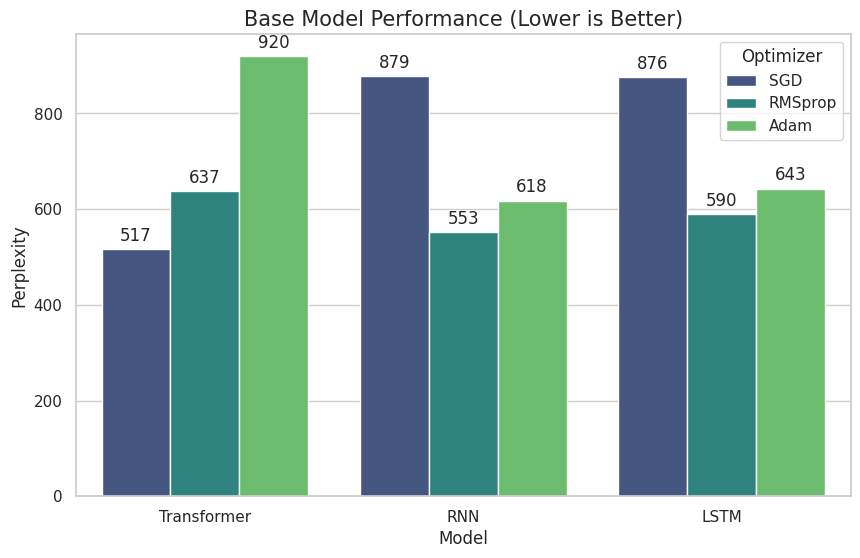

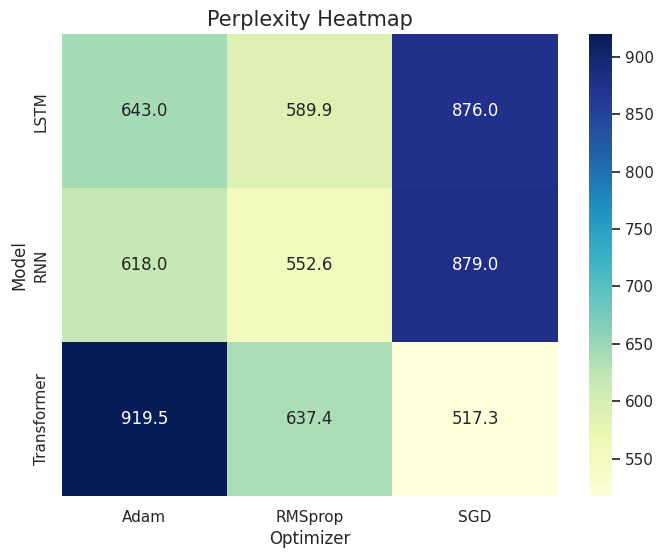

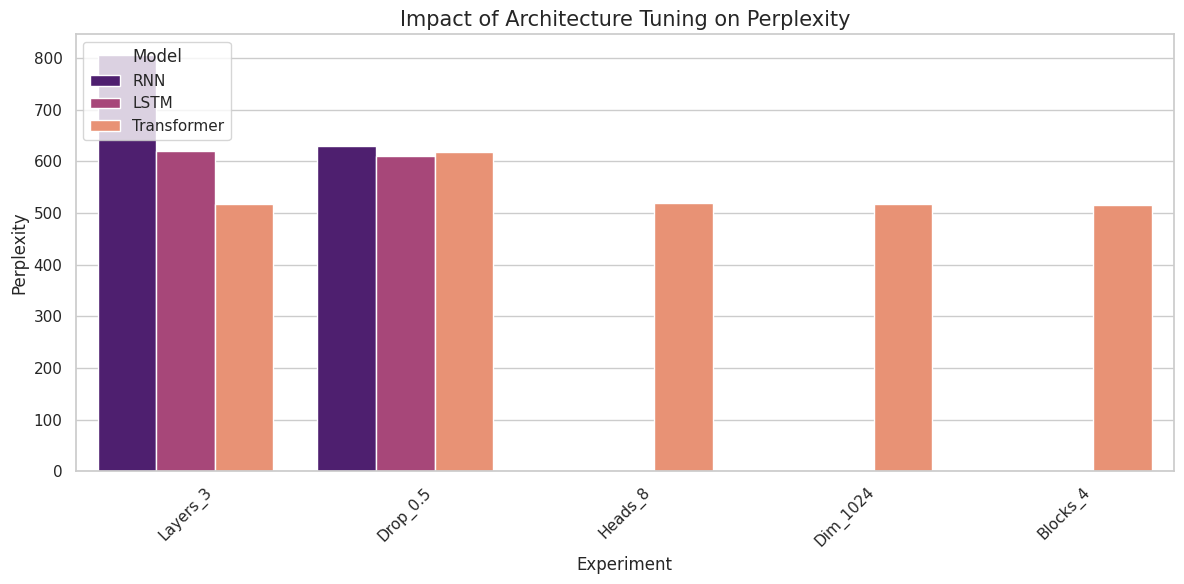

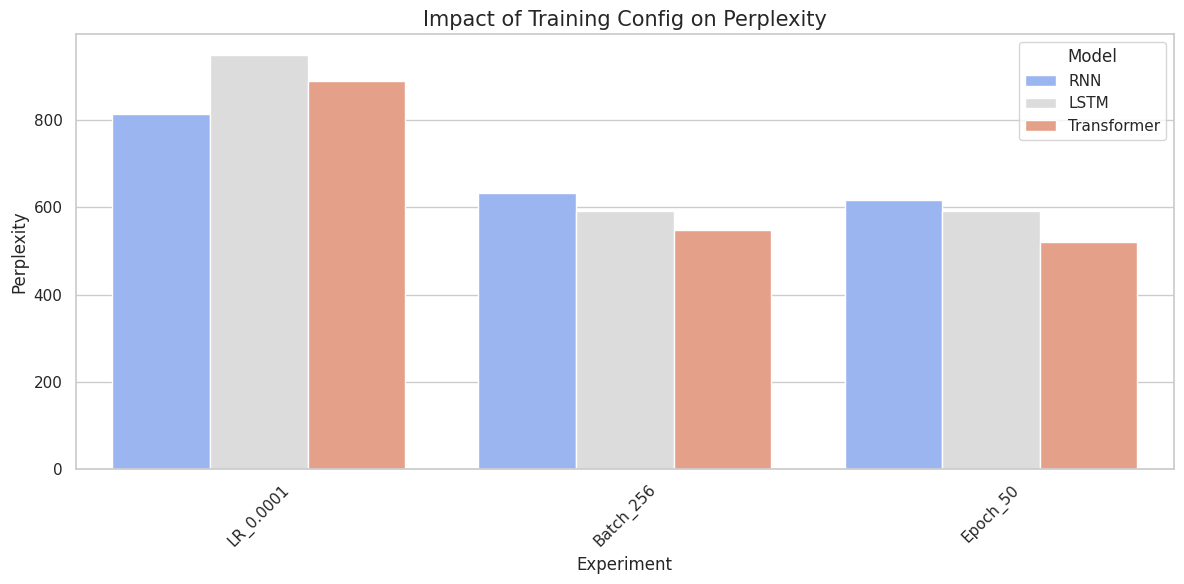

✅ All Visualizations saved as PNG files!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df_base = pd.read_csv("base_model_perplexity.csv")
df_tuning = pd.read_csv("FINAL_TUNING_RESULTS.csv")

sns.set_theme(style="whitegrid")

# --- PLOT 1: BASE MODEL COMPARISON ---
plt.figure(figsize=(10, 6))
chart = sns.barplot(data=df_base, x='Model', y='Perplexity', hue='Optimizer', palette='viridis')
plt.title('Base Model Performance (Lower is Better)', fontsize=15)
plt.ylabel('Perplexity')
for container in chart.containers:
    chart.bar_label(container, fmt='%.0f', padding=3)
plt.savefig('Viz_1_Base_Comparison.png')
plt.show()

# --- PLOT 2: HEATMAP ---
pivot = df_base.pivot(index='Model', columns='Optimizer', values='Perplexity')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Perplexity Heatmap', fontsize=15)
plt.savefig('Viz_2_Heatmap.png')
plt.show()

# --- PLOT 3: TUNING RESULTS (ARCHITECTURE) ---
# Filter for architecture changes (Layers, Drop, Heads, Blocks)
arch_params = ['layers', 'drop', 'heads', 'blocks', 'ff_dim']
df_arch = df_tuning[df_tuning['Parameter'].isin(arch_params)]

if not df_arch.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_arch, x='Experiment', y='Perplexity', hue='Model', palette='magma')
    plt.title('Impact of Architecture Tuning on Perplexity', fontsize=15)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('Viz_3_Tuning_Architecture.png')
    plt.show()

# --- PLOT 4: TUNING RESULTS (TRAINING) ---
# Filter for training changes (LR, Batch, Epoch)
train_params = ['lr', 'batch', 'epoch']
df_train = df_tuning[df_tuning['Parameter'].isin(train_params)]

if not df_train.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_train, x='Experiment', y='Perplexity', hue='Model', palette='coolwarm')
    plt.title('Impact of Training Config on Perplexity', fontsize=15)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('Viz_4_Tuning_Training.png')
    plt.show()
    
print("✅ All Visualizations saved as PNG files!")

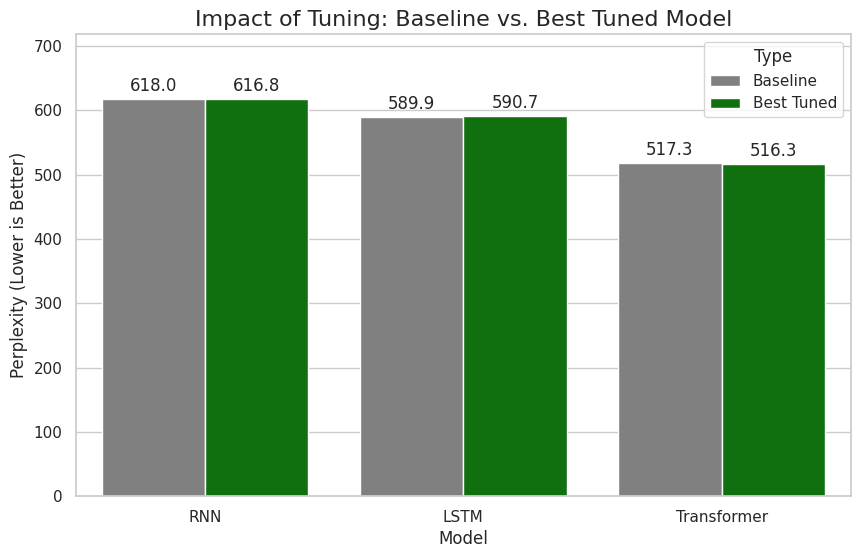

✅ Generated 'Viz_6_Before_After_Tuning.png'. Use this in your Conclusion!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df_base = pd.read_csv("base_model_perplexity.csv")
df_tuning = pd.read_csv("FINAL_TUNING_RESULTS.csv")

# 1. IDENTIFY THE 3 MAIN CATEGORIES (The Winners we chose to tune)
# RNN + Adam
# LSTM + RMSprop
# Transformer + SGD
target_combos = [
    ("RNN", "Adam"),
    ("LSTM", "RMSprop"),
    ("Transformer", "SGD")
]

comparison_data = []

for m_type, opt in target_combos:
    # A. Get Baseline Score
    base_row = df_base[(df_base['Model'] == m_type) & (df_base['Optimizer'] == opt)]
    if not base_row.empty:
        base_perp = base_row.iloc[0]['Perplexity']
        comparison_data.append({
            "Model": m_type,
            "Type": "Baseline",
            "Perplexity": base_perp
        })
    
    # B. Get Best Tuned Score
    # Filter tuning results for this model/optimizer
    tuned_rows = df_tuning[(df_tuning['Model'] == m_type) & (df_tuning['Optimizer'] == opt)]
    if not tuned_rows.empty:
        # Find the minimum perplexity achieved
        best_tuned = tuned_rows.loc[tuned_rows['Perplexity'].idxmin()]
        comparison_data.append({
            "Model": m_type,
            "Type": "Best Tuned",
            "Perplexity": best_tuned['Perplexity']
        })

# 2. PLOT THE COMPARISON
df_comp = pd.DataFrame(comparison_data)

plt.figure(figsize=(10, 6))
chart = sns.barplot(data=df_comp, x='Model', y='Perplexity', hue='Type', palette=['gray', 'green'])

plt.title('Impact of Tuning: Baseline vs. Best Tuned Model', fontsize=16)
plt.ylabel('Perplexity (Lower is Better)')
plt.ylim(0, df_comp['Perplexity'].max() + 100)

# Add numbers on top of bars
for container in chart.containers:
    chart.bar_label(container, fmt='%.1f', padding=3)

plt.savefig('Viz_6_Before_After_Tuning.png')
plt.show()

print("✅ Generated 'Viz_6_Before_After_Tuning.png'. Use this in your Conclusion!")